# Libreta 201 - Introducción a ML/DL

Alan Badillo Salas

dragonnomada123@gmail.com

...

In [3]:
%pip install numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

## Fase 1 - Construcción del Cubo de Datos

1. Adquirir el Conjunto de Datos
2. Construir los ejes de análisis (ejes de datos / series de datos)
3. Diseñar el Cubo de Datos (convertir cada eje de datos en series numéricas)
4. (Opcional) Visualizar y analizar el Cubo de Datos

In [5]:
# local: conjuntos/student_habits_performance.csv
# git: https://github.com/dragonnomada/ia-cic-abril-2026/blob/main/conjuntos/student_habits_performance.csv?raw=true
url = "https://raw.githubusercontent.com/dragonnomada/ia-cic-abril-2026/refs/heads/main/conjuntos/student_habits_performance.csv"

students = pandas.read_csv(url)

students.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


In [6]:
e1 = students["age"]
e2 = students["gender"]
e3 = students["study_hours_per_day"]
e4 = students["social_media_hours"]
e5 = students["netflix_hours"]
e6 = students["part_time_job"]
e7 = students["attendance_percentage"]
e8 = students["sleep_hours"]
e9 = students["diet_quality"]
e10 = students["exercise_frequency"]
e11 = students["parental_education_level"]
e12 = students["internet_quality"]
e13 = students["mental_health_rating"]
e14 = students["extracurricular_participation"]
e15 = students["exam_score"]

In [7]:
x1 = e1 # Edad - 17-24
x2 = (e2 == "Male").astype(int) # Género Hombre - 0,1
x2.name = "is_male"
x3 = (e2 == "Other").astype(int) # Género Otro - 0,1
x3.name = "is_other"
x4 = e3 # Horas de estudio - 0-8.3
x5 = e4 # Horas de redes soc. - 0-7.2
x6 = e5 # Horas de netflix - 0-5.4
x7 = (e6 == "Yes").astype(int) # Trabajo medio tiempo - 0,1
x7.name = "part_time_job" 
x8 = e7 # Porcentaje de asistencia - 0-100
x9 = e8 # Horas de sueño
# dummies
# x10 = (e9 == "Poor").astype(int) # numérico 0,1
# x11 = (e9 == "Good").astype(int) # numérico 0,1
x10 = e9.map({
    "Poor": -1,
    "Fair": 0,
    "Good": 1,
}) # Calidad de la dieta: -1,0,1
x11 = e10 # Frecuencia de ejercicio: 0 a 6
x12 = e11.map({
    "High School": 1,
    "Bachelor": 2,
    "Master": 4,
}).fillna(1.5) # Nivel educativo de los padres: 1,2,4
x13 = e12.map({
    "Poor": -2,
    "Average": 1,
    "Good": 2,
}) # Calidad de internet: -2,1,2
x14 = e13 # Puntuación de salud mental: 1 al 10
x15 = (e14 == "Yes").astype(int) # Participación extra.: 0,1
x15.name = "extracurricular"

y = e15


In [8]:
X = pandas.DataFrame([
    x1, x2, x3,
    x4, x5, x6,
    x7, x8, x9,
    x10, x11, x12,
    x13, x14, x15
]).T

In [9]:
X

,age,is_male,is_other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular
0,23.0,0.0,0.0,0.0,1.2,1.1,0.0,85.0,8.0,0.0,6.0,4.0,1.0,8.0,1.0
1,20.0,0.0,0.0,6.9,2.8,2.3,0.0,97.3,4.6,1.0,6.0,1.0,1.0,8.0,0.0
2,21.0,1.0,0.0,1.4,3.1,1.3,0.0,94.8,8.0,-1.0,1.0,1.0,-2.0,1.0,0.0
3,23.0,0.0,0.0,1.0,3.9,1.0,0.0,71.0,9.2,-1.0,4.0,4.0,2.0,1.0,1.0
4,19.0,0.0,0.0,5.0,4.4,0.5,0.0,90.9,4.9,0.0,3.0,4.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21.0,0.0,0.0,2.6,0.5,1.6,0.0,77.0,7.5,0.0,2.0,1.0,2.0,6.0,1.0
996,17.0,0.0,0.0,2.9,1.0,2.4,1.0,86.0,6.8,-1.0,1.0,1.0,1.0,6.0,1.0
997,20.0,1.0,0.0,3.0,2.6,1.3,0.0,61.9,6.5,1.0,5.0,2.0,2.0,9.0,1.0
998,24.0,1.0,0.0,5.4,4.1,1.1,1.0,100.0,7.6,0.0,0.0,2.0,1.0,1.0,0.0


In [10]:
X.describe()

,age,is_male,is_other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular
count,1000.0000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,0.477000,0.04200,3.55010,2.505500,1.819700,0.215000,84.131700,6.470100,0.19300,3.042000,1.896500,0.961000,5.438000,0.318000
std,2.3081,0.499721,0.20069,1.46889,1.172422,1.075118,0.411028,9.399246,1.226377,0.72545,2.025423,1.035911,1.380357,2.847501,0.465932
min,17.0000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,56.000000,3.200000,-1.00000,0.000000,1.000000,-2.000000,1.000000,0.000000
25%,18.7500,0.000000,0.00000,2.60000,1.700000,1.000000,0.000000,78.000000,5.600000,0.00000,1.000000,1.000000,1.000000,3.000000,0.000000
50%,20.0000,0.000000,0.00000,3.50000,2.500000,1.800000,0.000000,84.400000,6.500000,0.00000,3.000000,2.000000,1.000000,5.000000,0.000000
75%,23.0000,1.000000,0.00000,4.50000,3.300000,2.525000,0.000000,91.025000,7.300000,1.00000,5.000000,2.000000,2.000000,8.000000,1.000000
max,24.0000,1.000000,1.00000,8.30000,7.200000,5.400000,1.000000,100.000000,10.000000,1.00000,6.000000,4.000000,2.000000,10.000000,1.000000


In [11]:
from sklearn.preprocessing import StandardScaler

Xs = pandas.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

Xs

,age,is_male,is_other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular
0,1.084551,-0.955011,-0.209383,-2.418068,-1.114064,-0.669750,-0.523341,0.092426,1.248120,-0.266175,1.461166,2.031597,0.028268,0.900186,1.464464
1,-0.215870,-0.955011,-0.209383,2.281707,0.251315,0.446965,-0.523341,1.401696,-1.525661,1.112970,1.461166,-0.865855,0.028268,0.900186,-0.682844
2,0.217604,1.047108,-0.209383,-1.464491,0.507324,-0.483631,-0.523341,1.135584,1.248120,-1.645320,-1.008689,-0.865855,-2.146171,-1.559339,-0.682844
3,1.084551,-0.955011,-0.209383,-1.736942,1.190013,-0.762810,-0.523341,-1.397800,2.227102,-1.645320,0.473224,2.031597,0.753081,-1.559339,1.464464
4,-0.649344,-0.955011,-0.209383,0.987566,1.616694,-1.228108,-0.523341,0.720450,-1.280916,-0.266175,-0.020747,2.031597,0.753081,-1.559339,-0.682844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.217604,-0.955011,-0.209383,-0.647139,-1.711417,-0.204452,-0.523341,-0.759132,0.840211,-0.266175,-0.514718,-0.865855,0.753081,0.197465,1.464464
996,-1.516291,-0.955011,-0.209383,-0.442801,-1.284736,0.540025,1.910802,0.198871,0.269138,-1.645320,-1.008689,-0.865855,0.028268,0.197465,1.464464
997,-0.215870,1.047108,-0.209383,-0.374688,0.080643,-0.483631,-0.523341,-2.366448,0.024393,1.112970,0.967195,0.099962,0.753081,1.251547,1.464464
998,1.518025,1.047108,-0.209383,1.260017,1.360685,-0.669750,1.910802,1.689097,0.921793,-0.266175,-1.502660,0.099962,0.028268,-1.559339,-0.682844


In [12]:
Xs.describe()

,age,is_male,is_other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-4.760636e-16,1.065814e-16,-3.552714e-17,-3.375078e-17,-1.570299e-15,-1.321609e-15,-3.907985e-17,-2.508216e-15,1.101341e-15,-4.440892e-17,1.110223e-16,-7.105427e-17,8.926193e-17,9.237056e-17,-3.552714e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.516291e+00,-9.550109e-01,-2.093832e-01,-2.418068e+00,-2.138098e+00,-1.693406e+00,-5.233406e-01,-2.994472e+00,-2.667807e+00,-1.645320e+00,-1.502660e+00,-8.658552e-01,-2.146171e+00,-1.559339e+00,-6.828438e-01
25%,-7.577120e-01,-9.550109e-01,-2.093832e-01,-6.471386e-01,-6.873828e-01,-7.628097e-01,-5.233406e-01,-6.526872e-01,-7.098433e-01,-2.661750e-01,-1.008689e+00,-8.658552e-01,2.826771e-02,-8.566176e-01,-6.828438e-01
50%,-2.158699e-01,-9.550109e-01,-2.093832e-01,-3.412446e-02,-4.693489e-03,-1.833275e-02,-5.233406e-01,2.855913e-02,2.439296e-02,-2.661750e-01,-2.074679e-02,9.996209e-02,2.826771e-02,-1.538960e-01,-6.828438e-01
75%,1.084551e+00,1.047108e+00,-2.093832e-01,6.470024e-01,6.779959e-01,6.563495e-01,-5.233406e-01,7.337556e-01,6.770474e-01,1.112970e+00,9.671954e-01,9.996209e-02,7.530807e-01,9.001864e-01,1.464464e+00
max,1.518025e+00,1.047108e+00,4.775932e+00,3.235284e+00,4.006106e+00,3.331814e+00,1.910802e+00,1.689097e+00,2.879756e+00,1.112970e+00,1.461166e+00,2.031597e+00,7.530807e-01,1.602908e+00,1.464464e+00


In [13]:
ys = (y - y.mean()) / y.std()

ys

0     -0.793525
1      1.799946
2     -2.090261
3     -2.534348
4     -0.189566
         ...   
995    0.384787
996   -0.219172
997   -0.307989
998    0.005832
999    0.313733
Name: exam_score, Length: 1000, dtype: float64

## Red Neuronal Profunda (Deep Learning / Aprendizaje Profundo)

In [14]:
import keras # Instalar Tensorflow

model = keras.Sequential([
    keras.Input(shape=(15,)),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer="sgd",
    loss="mse",
    metrics=["mse", "mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 100)            │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,001 (125.00 KB)

 Trainable params: 32,001 (125.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Épocas - Reforzar muchas veces el mismo conocimiento
# Lotes - Separar muestras de entrenamiento

model.fit(Xs, ys, epochs=1000, batch_size=500)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1059 - mae: 0.2626 - mse: 0.1059
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1064 - mae: 0.2645 - mse: 0.1064
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1042 - mae: 0.2603 - mse: 0.1042
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1061 - mae: 0.2632 - mse: 0.1061
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1046 - mae: 0.2616 - mse: 0.1046
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1020 - mae: 0.2572 - mse: 0.1020
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0996 - mae: 0.2533 - mse: 0.0996
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1016 - mae: 0.2575 - mse: 0.1016
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.1044 - mae: 0.2603 - mse: 0.1044
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1004 - mae: 0.2558 - mse: 0.1004
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss

In [21]:
yp = model.predict(Xs)[:, 0]

pandas.DataFrame([ys, yp]).T

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,exam_score,Unnamed 0
0,-0.793525,-0.882907
1,1.799946,1.703769
2,-2.090261,-2.018424
3,-2.534348,-2.304727
4,-0.189566,-0.140257
...,...,...
995,0.384787,0.000910
996,-0.219172,-0.295030
997,-0.307989,-0.152277
998,0.005832,-0.009060


<Axes: ylabel='exam_score'>

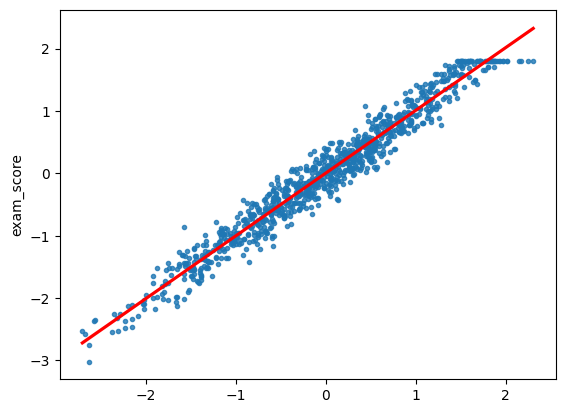

In [24]:
seaborn.regplot(x=yp, y=ys, line_kws={"color": "red"}, marker=".")

In [25]:
e = ys - yp # Error

SSE = (e ** 2).sum() # Sum Square Error
MSE = (e ** 2).mean() # Mean Square Error
RMSE = (e ** 2).mean() ** 0.5 # Root Mean Square Error
SAE = e.abs().sum() # Sum Absolute Error
MAE = e.abs().mean() # Mean Absolute Error

pandas.DataFrame({
    "N": [len(e)],
    "SSE": [SSE],
    "MSE": [MSE],
    "RMSE": [RMSE],
    "SAE": [SAE],
    "MAE": [MAE],
}).T

,0
N,1000.000000
SSE,40.285693
MSE,0.040286
RMSE,0.200713
SAE,160.256303
MAE,0.160256


In [26]:
e = (ys * y.std() + y.mean()) - (yp * y.std() + y.mean()) # Error

SSE = (e ** 2).sum() # Sum Square Error
MSE = (e ** 2).mean() # Mean Square Error
RMSE = (e ** 2).mean() ** 0.5 # Root Mean Square Error
SAE = e.abs().sum() # Sum Absolute Error
MAE = e.abs().mean() # Mean Absolute Error

pandas.DataFrame({
    "N": [len(e)],
    "SSE": [SSE],
    "MSE": [MSE],
    "RMSE": [RMSE],
    "SAE": [SAE],
    "MAE": [MAE],
}).T

,0
N,1000.000000
SSE,11490.429946
MSE,11.490430
RMSE,3.389754
SAE,2706.498823
MAE,2.706499
